# Taller Práctico: El Arte de la Generalización y Ajuste de Modelos en Homecenter
## Diagnóstico y Mitigación del Sobreajuste (Overfitting)

**Profesor:** [Tu Nombre / Departamento]  
**Metodología:** Aprendizaje Activo y Basado en Evidencia (Estilo Andrew Ng)

---

## 1. Introducción Teórica: La Lucha entre el Sesgo y la Varianza

Como revisamos en nuestra sesión teórica (referencia: **Diapositivas 1-4**), el objetivo de un modelo de Machine Learning es encontrar patrones generalizables, no memorizar el ruido de los datos.

Recordemos la **Descomposición del Error de Pronóstico** (Diapositiva 2):
$$
E\left[(h - y)^2\right] = \text{Varianza}(x) + \text{Ruido}(x) + \text{Sesgo}^2(x)
$$

Donde:
*   **Varianza (Variance):** Qué tanto cambia el pronóstico del modelo según el dataset de entrenamiento utilizado. Alta varianza implica **Sobreajuste (Overfitting)** (Régimen 1 - Diapositiva 14).
*   **Sesgo (Bias):** Qué tanto se aleja el promedio de nuestras predicciones del objetivo real. Alto sesgo implica **Subajuste (Underfitting)** (Régimen 2 - Diapositiva 14).
*   **Ruido:** El error irreducible inherente a la naturaleza de los datos.

Para combatir la alta varianza, aplicamos técnicas de **Regularización** (Diapositivas 8-12), las cuales penalizan la complejidad del modelo añadiendo un castigo a la función de costo (como Lasso L1, Ridge L2 o Elastic Net).

In [ ]:
# INSTALACIÓN DE LIBRERÍAS (Ejecuta esta celda si estás en Codespaces para asegurar las dependencias)
# !pip install pycaret sweetviz ipywidgets scikit-learn pandas numpy matplotlib seaborn

---
## 2. Simulador Interactivo: Regularización L2 en Tiempo Real

Antes de modelar el dataset completo de **Homecenter**, experimentemos con un simulador interactivo. 

Aquí modelamos la relación entre los *Años de Antigüedad del Cliente* en Homecenter y su *Gasto Anual (en millones de COP)*. 

### Instrucciones del Experimento:
1. Ejecuta la celda inferior.
2. Modifica el **Grado Polinomial** (Complejidad del Modelo) a un valor alto (ej. 9 o 10) con **Alpha (Regularización $\lambda$)** en `0.0` (sin regularización). Observa cómo la curva trata de "tocar" cada punto, aumentando el error en Test.
3. Sin bajar el grado del polinomio, incrementa el valor de **Alpha ($\lambda$)**. Observa cómo la curva se suaviza (se regulariza) y el error de Test disminuye. ¡Has controlado la varianza de forma matemática!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from ipywidgets import interact

# Generar datos del simulador interactivo
np.random.seed(15)
x_sim = np.random.uniform(0.5, 6, 30)
y_sim = 1.2 * (x_sim ** 2.2) - 3 * x_sim + np.random.normal(0, 5, 30) + 10

x_train_s, x_test_s = x_sim[:20], x_sim[20:]
y_train_s, y_test_s = y_sim[:20], y_sim[20:]

def simular_ajuste(grado_polinomio, alpha_regularizacion):
    # Crear pipeline con variables polinomiales y regresión Ridge (L2)
    modelo = make_pipeline(
        PolynomialFeatures(degree=grado_polinomio, include_bias=False),
        Ridge(alpha=alpha_regularizacion, random_state=42)
    )
    
    modelo.fit(x_train_s.reshape(-1, 1), y_train_s)
    
    # Generar curva de predicción
    x_curva = np.linspace(0.1, 6.5, 200).reshape(-1, 1)
    y_curva = modelo.predict(x_curva)
    
    # Métricas
    mse_train = mean_squared_error(y_train_s, modelo.predict(x_train_s.reshape(-1, 1)))
    mse_test = mean_squared_error(y_test_s, modelo.predict(x_test_s.reshape(-1, 1)))
    
    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.scatter(x_train_s, y_train_s, color='blue', label=f'Train (n=20)', alpha=0.7, s=80)
    plt.scatter(x_test_s, y_test_s, color='orange', marker='s', label=f'Test (n=10)', alpha=0.8, s=80)
    plt.plot(x_curva, y_curva, color='red', lw=2.5, label=f'Modelo (Grado {grado_polinomio})')
    
    plt.ylim(-5, 45)
    plt.title(f"Homecenter: Relación Antigüedad vs Gasto (Penalización L2 \\lambda = {alpha_regularizacion})", fontsize=13)
    plt.xlabel("Años de Antigüedad del Cliente")
    plt.ylabel("Gasto Anual (Millones COP)")
    
    # Mostrar métricas en el plot
    plt.text(0.5, 40, f"RMSE Train: {np.sqrt(mse_train):.2f}", color='blue', fontsize=11, fontweight='bold')
    plt.text(0.5, 37, f"RMSE Test: {np.sqrt(mse_test):.2f}", color='orange', fontsize=11, fontweight='bold')
    
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Crear interfaz interactiva
interact(
    simular_ajuste, 
    grado_polinomio=widgets.IntSlider(min=1, max=10, step=1, value=1, description='Complejidad (D)'),
    alpha_regularizacion=widgets.FloatLogSlider(value=0.0001, base=10, min=-4, max=3, step=0.5, description='Regularización L2')
);

interactive(children=(IntSlider(value=1, description='Complejidad (D)', max=10, min=1), FloatLogSlider(value=0…

---
## 3. El Caso Práctico: Datos de Gasto en Homecenter

Generaremos un dataset sintético que represente a 1,000 clientes de **Homecenter**. 

### Variables:
*   `antiguedad_anos`: Años desde que el cliente se registró en el programa Círculo Especialistas/Puntos Homecenter.
*   `visitas_mes_app`: Promedio de ingresos mensuales a la aplicación móvil de Homecenter.
*   `articulos_proyecto`: Promedio de productos agregados al carro de compras enfocados en un proyecto de remodelación.
*   `id_tarjeta_tuya_ruido`: ID de la tarjeta de crédito de marca compartida (ruido aleatorio absoluto).
*   `clicks_publicidad_externa_ruido`: Clicks del cliente en banners de publicidad ajena a Homecenter (ruido).

### Ejercicio de Completar 1:
Completa las variables de ruido en el código para simular adecuadamente las "trampas" del dataset.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 1000

# Variables reales predictoras
antiguedad_anos = np.random.uniform(1, 8, n_samples)
visitas_mes_app = np.random.normal(25, 5, n_samples)
articulos_proyecto = np.random.poisson(5, n_samples)

# Target con relación no lineal
gasto_anual_millones = (
    5.0 
    + (1.2 * (antiguedad_anos ** 1.8)) 
    + (0.35 * visitas_mes_app) 
    + (0.8 * articulos_proyecto) 
    + np.random.normal(0, 2.5, n_samples)
)

# =========================================================================
# EJERCICIO: Completa los valores sintéticos de ruido usando numpy (np.random)
# =========================================================================
# Pista: id_tarjeta_tuya_ruido debe ser un entero aleatorio entre 100000 y 999999
# Pista: clicks_publicidad_externa_ruido debe ser una distribución normal con media 50 y desviación 15

id_tarjeta_tuya_ruido = np.random.randint(100000, 999999, n_samples) # FIXME
clicks_publicidad_externa_ruido = np.random.normal(50, 15, n_samples) # FIXME

# Construcción del DataFrame
df_homecenter = pd.DataFrame({
    'antiguedad_anos': antiguedad_anos,
    'visitas_mes_app': visitas_mes_app,
    'articulos_proyecto': articulos_proyecto,
    'id_tarjeta_tuya': id_tarjeta_tuya_ruido,
    'clicks_publicidad': clicks_publicidad_externa_ruido,
    'gasto_anual_millones_cop': gasto_anual_millones
})

print("Estructura del Dataset de Homecenter:")
print(df_homecenter.head())

Estructura del Dataset de Homecenter:
   antiguedad_anos  visitas_mes_app  articulos_proyecto  id_tarjeta_tuya  \
0         3.621781        25.888505                   5           355931   
1         7.655000        18.323278                   2           259996   
2         6.123958        26.900989                   1           750299   
3         5.190609        28.052929                   1           566185   
4         2.092130        27.798952                   7           392248   

   clicks_publicidad  gasto_anual_millones_cop  
0          44.235122                 31.556299  
1          42.472226                 58.158518  
2          72.969902                 46.630539  
3          55.056309                 38.089900  
4          29.983189                 25.184543  


---
## 4. Análisis Exploratorio de Datos (EDA) Descriptivo con Sweetviz

Ejecutaremos `Sweetviz` para analizar las distribuciones y correlaciones con el gasto anual de nuestros clientes en Homecenter. Busca el archivo HTML generado en tu espacio de trabajo.

                                             |          | [  0%]   00:00 -> (? left)


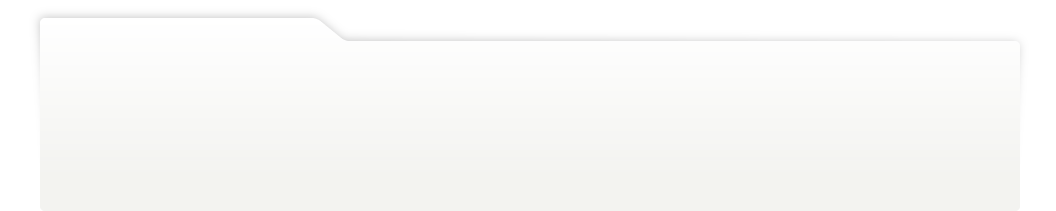
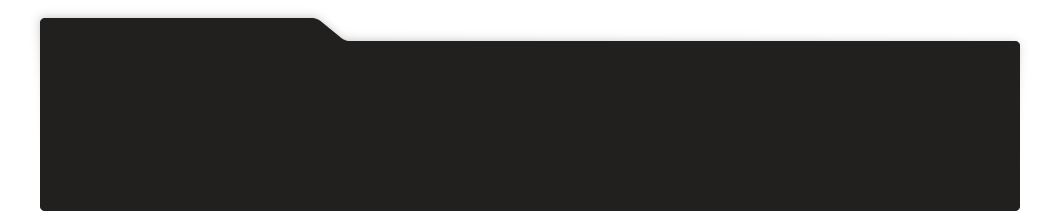
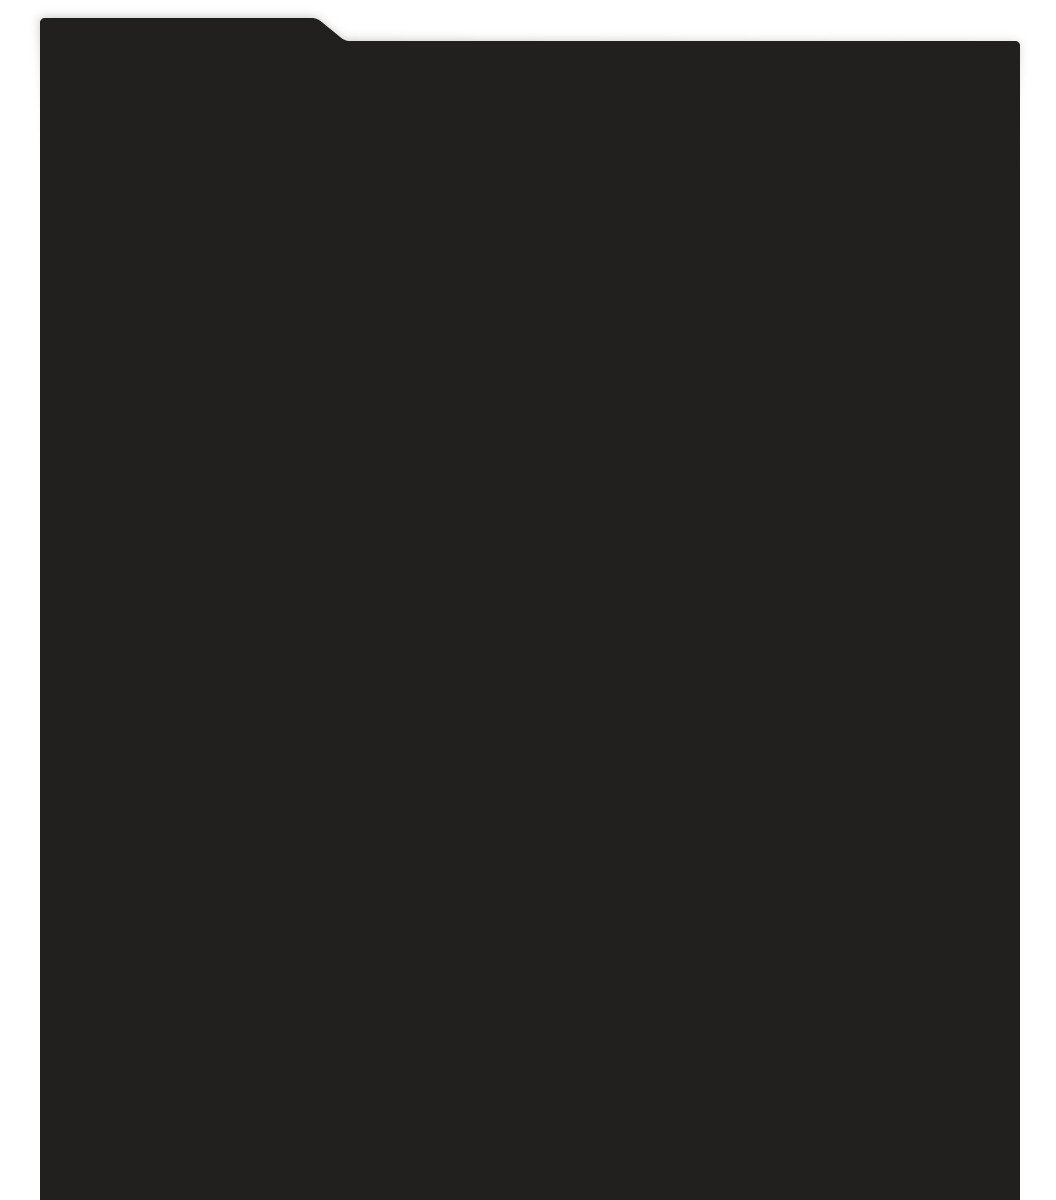
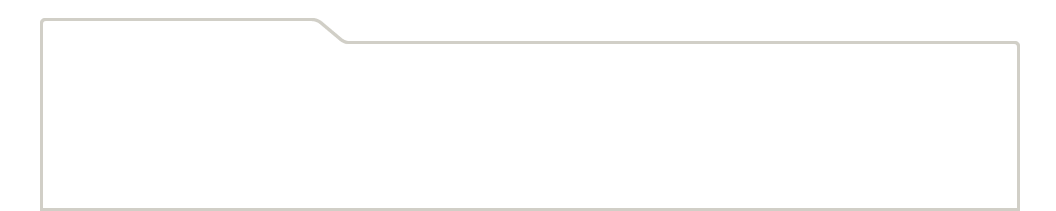
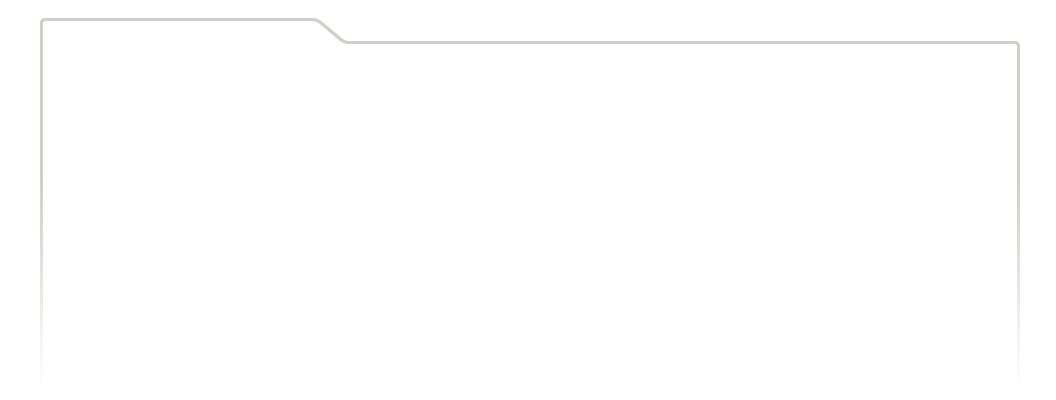
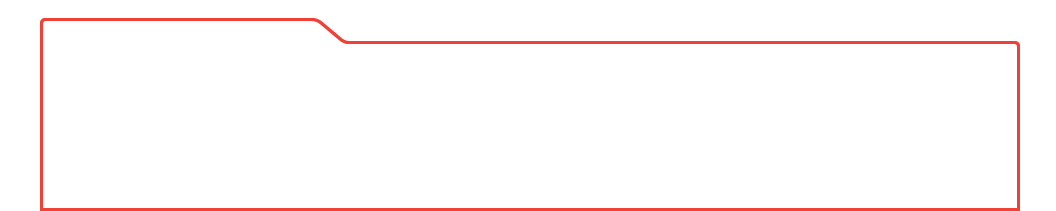
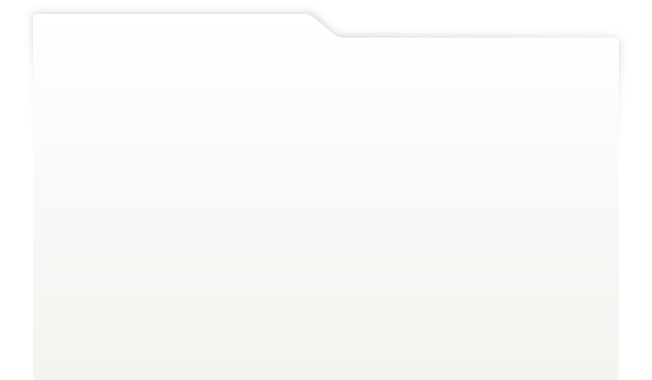
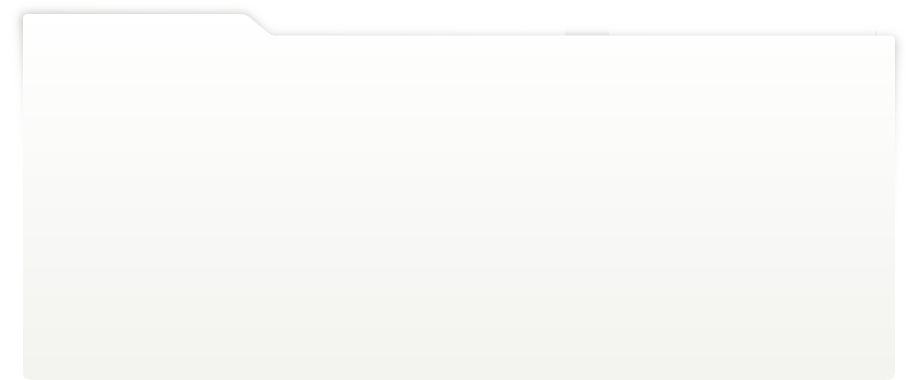
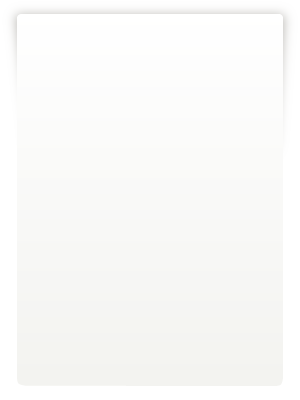
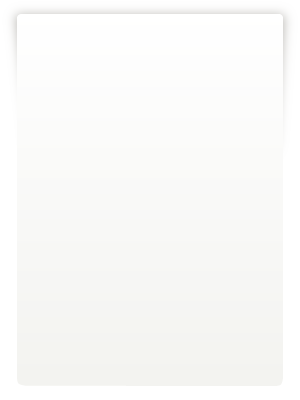
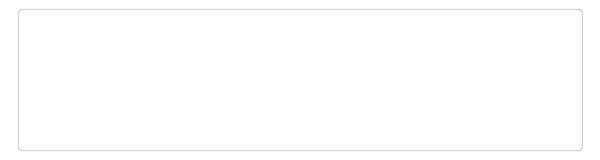
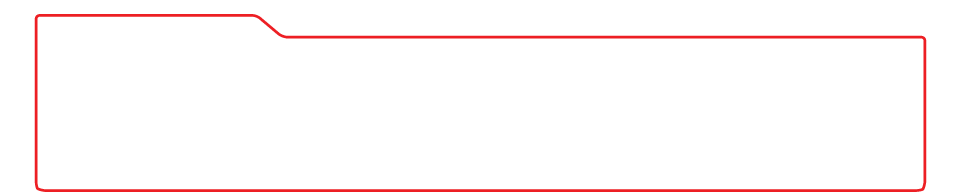
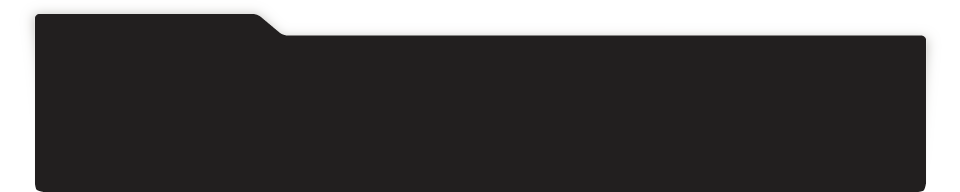
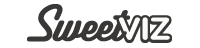
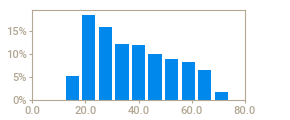
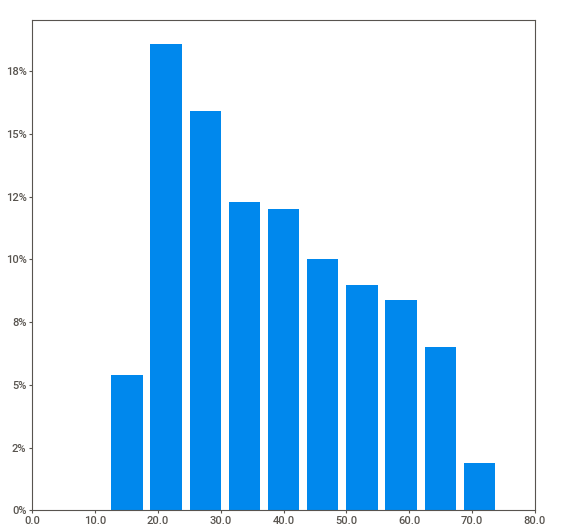
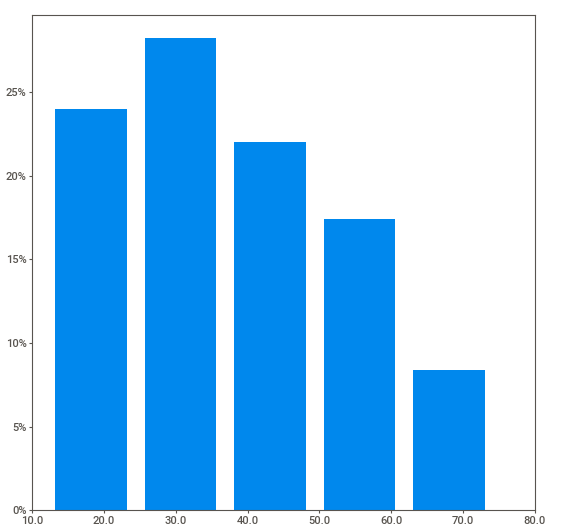
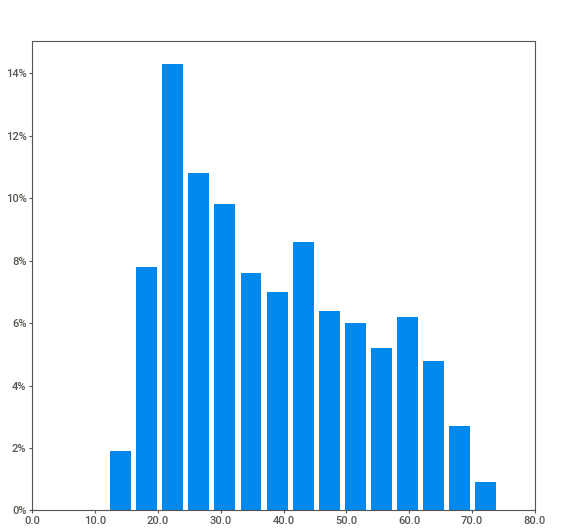
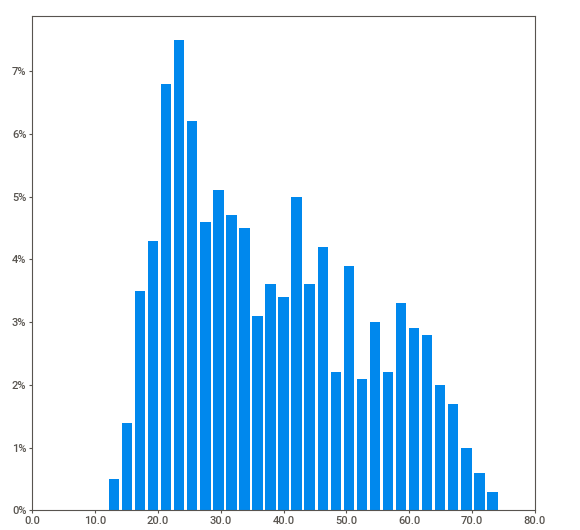
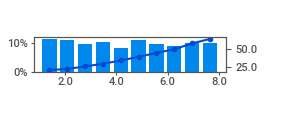
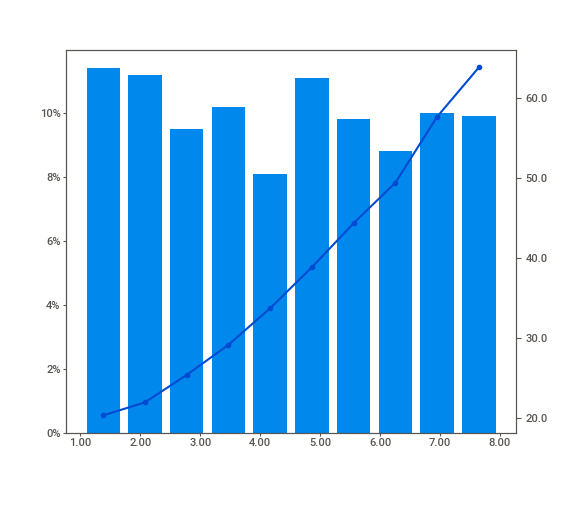
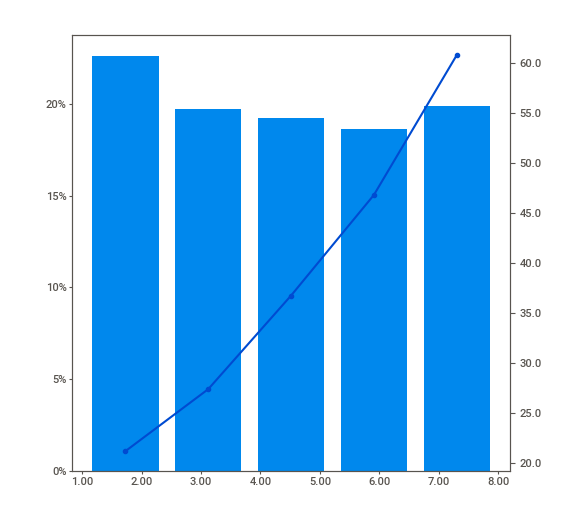
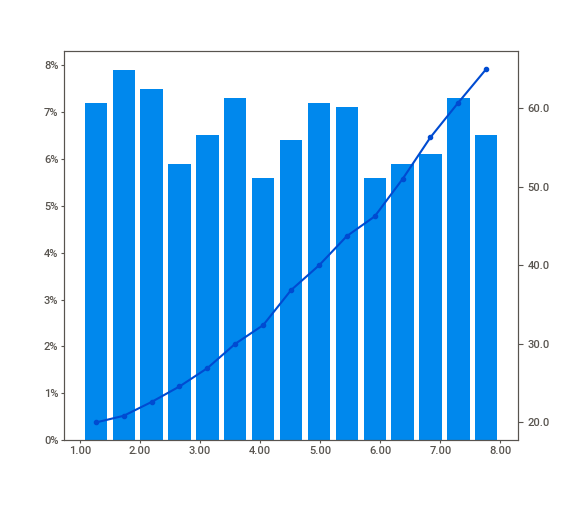
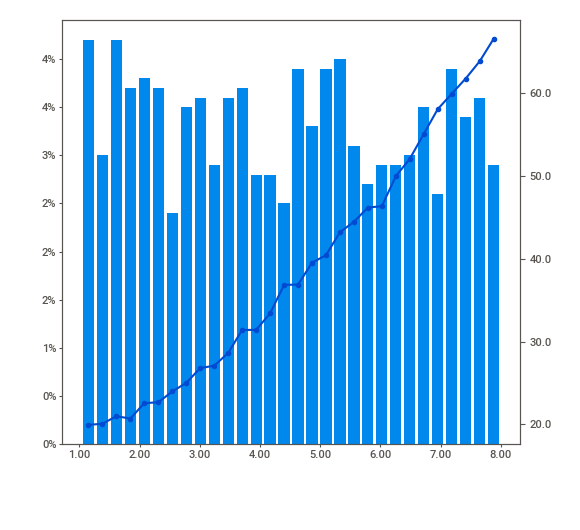
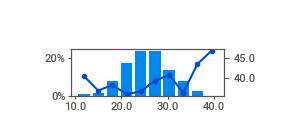
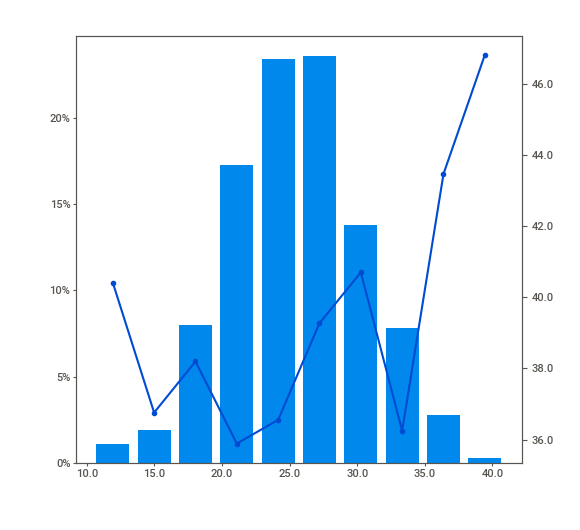
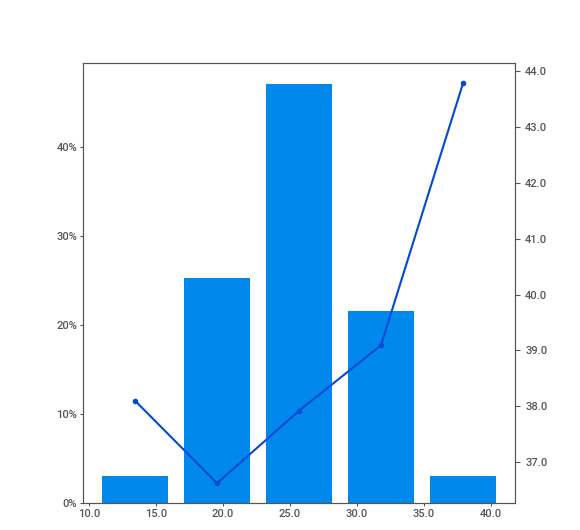
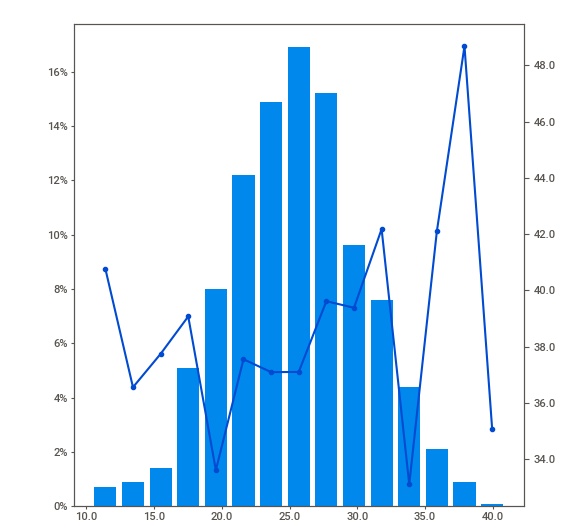
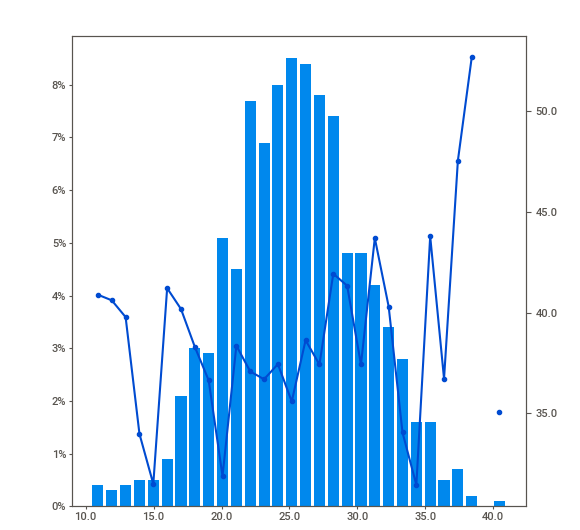
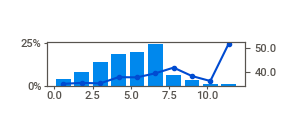
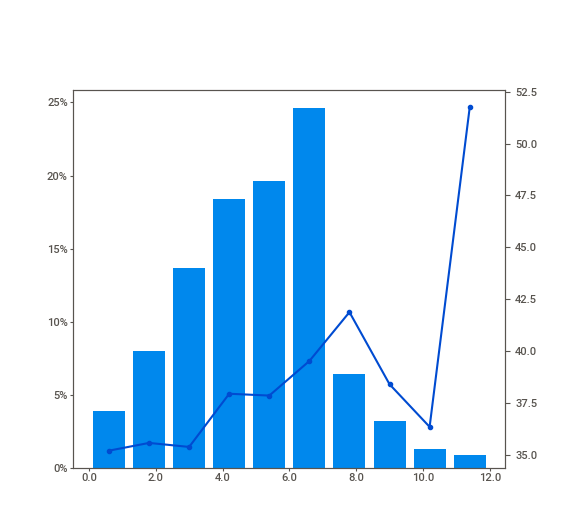
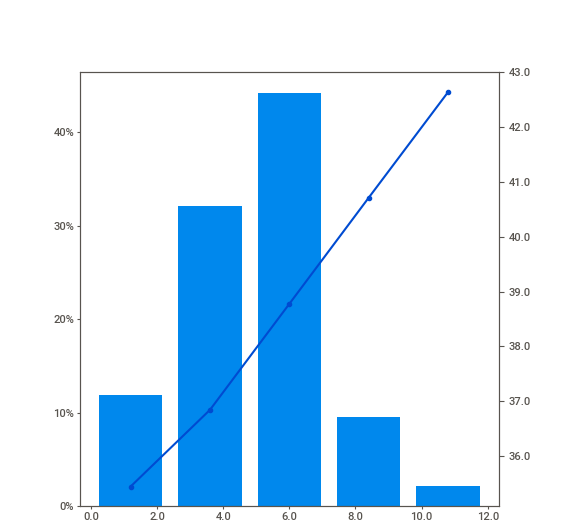
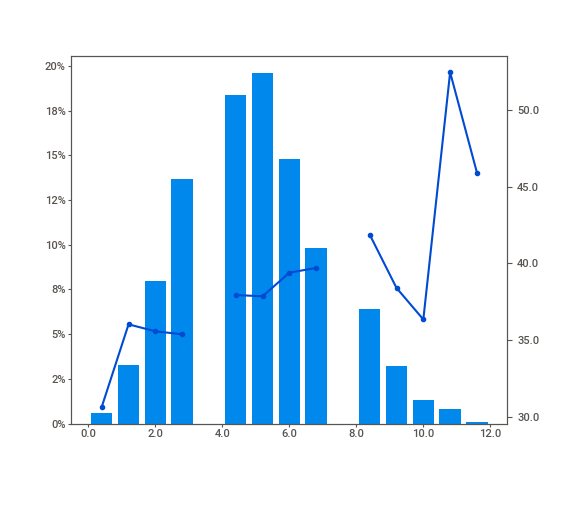
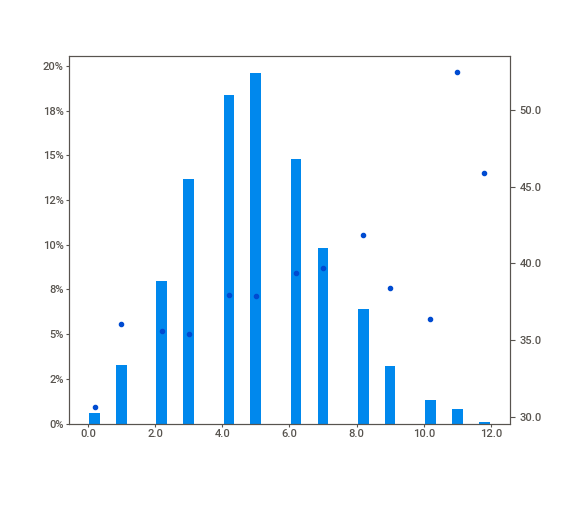
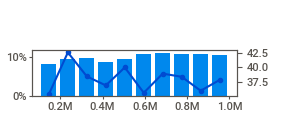
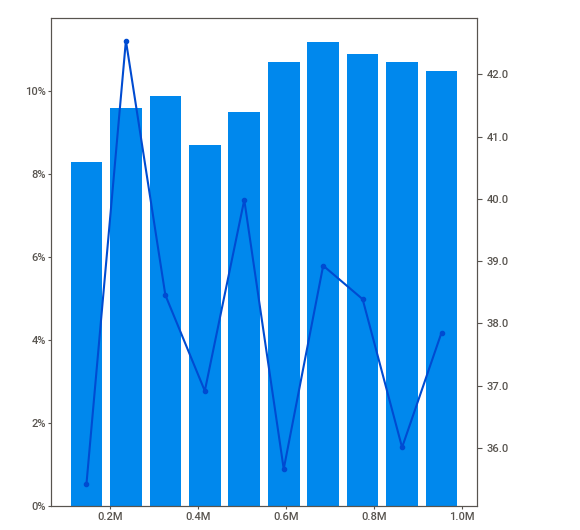
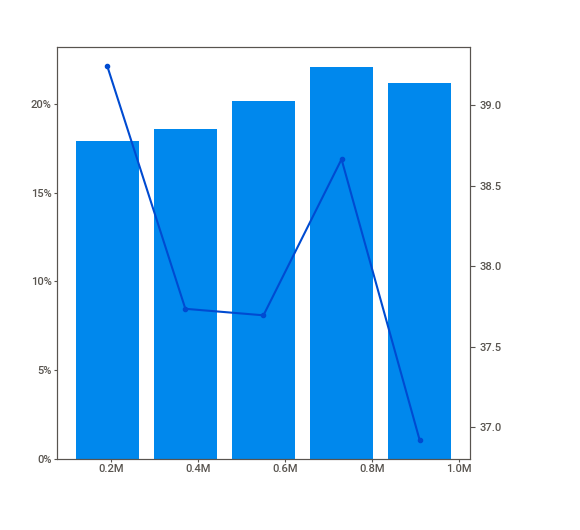
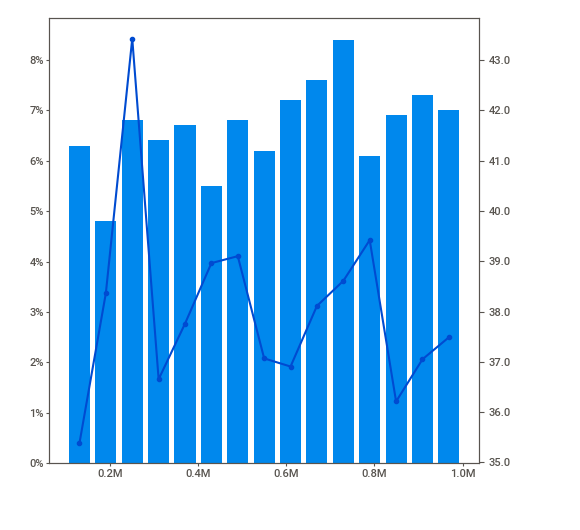
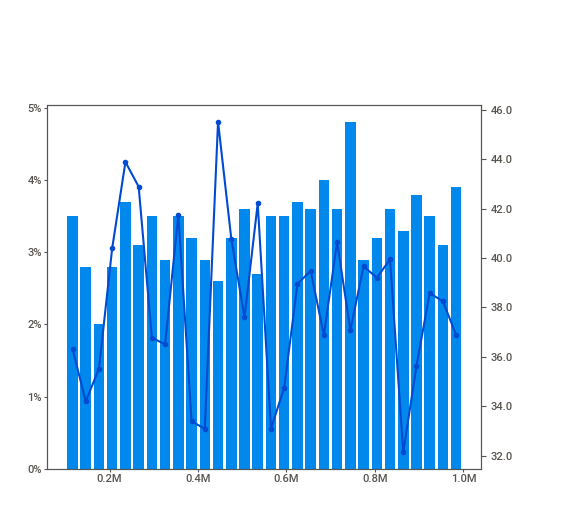
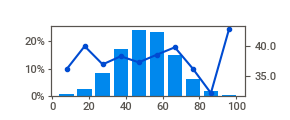
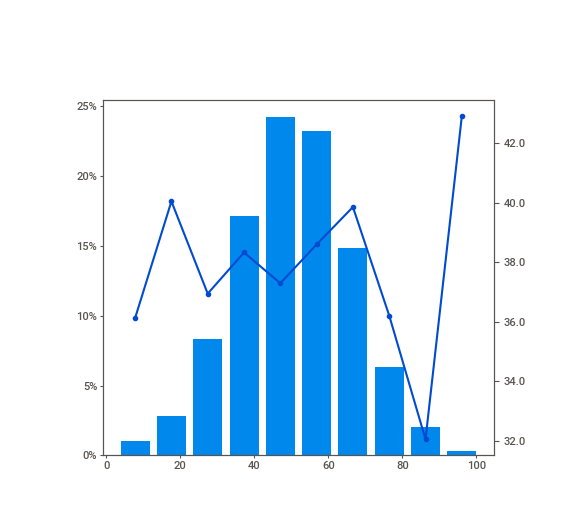
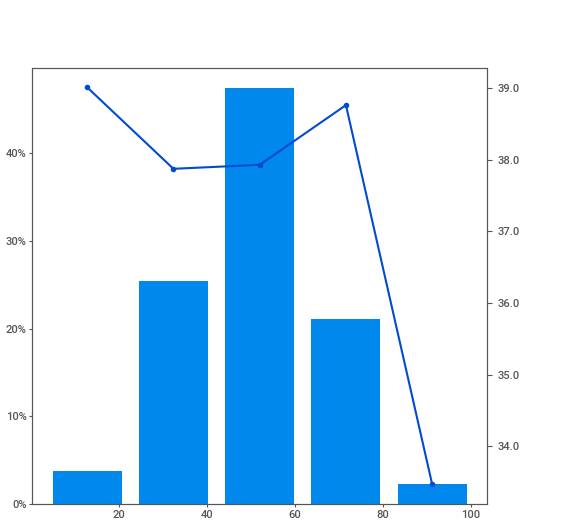
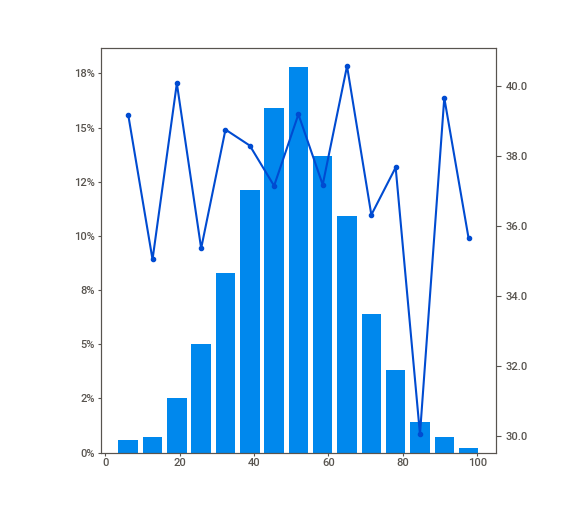
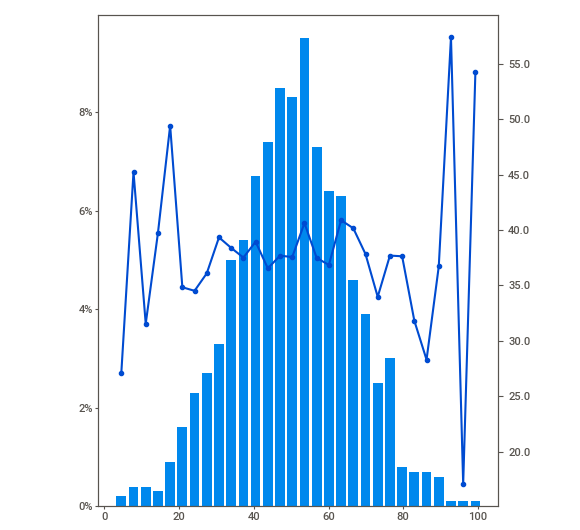
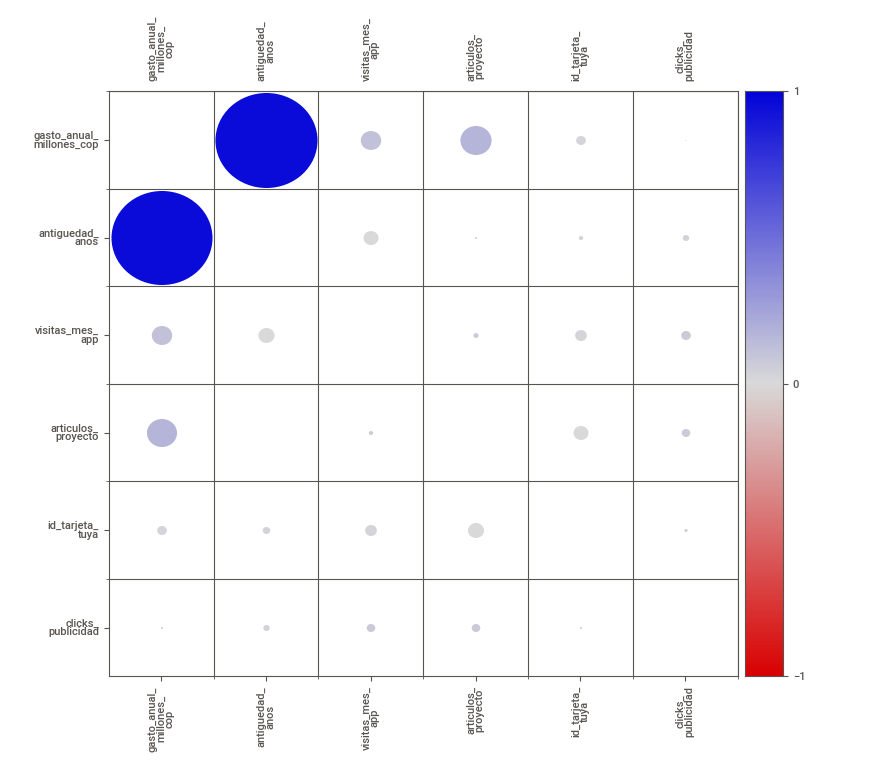
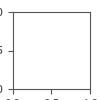

In [5]:
import sweetviz as sv

# Generación del Reporte Exploratorio
reporte_homecenter = sv.analyze(df_homecenter, target_feat='gasto_anual_millones_cop')
reporte_homecenter.show_notebook()

### Preguntas de Reflexión (Análisis Pre-Modelamiento):
1. Al examinar el reporte HTML, ¿qué fuerza de correlación lineal observas entre `gasto_anual_millones_cop` y `id_tarjeta_tuya`?
2. ¿Por qué es crítico descartar variables ruidosas antes de ajustar modelos de alta flexibilidad como árboles de decisión o redes neuronales?

---
## 5. La Tragedia del Sobreajuste: Un Modelo Sin Control

Modelaremos inicialmente los datos usando un **Árbol de Decisión Regresor** sin restricciones. Al no limitar su profundidad, el árbol subdividirá los datos hasta que cada hoja contenga prácticamente un solo dato de entrenamiento, memorizando el ruido.

### Ejercicio de Completar 2:
Instancia el regresor del Árbol de Decisión sin límites de profundidad para provocar el sobreajuste deliberado.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Separación de variables
X = df_homecenter.drop(columns=['gasto_anual_millones_cop'])
y = df_homecenter['gasto_anual_millones_cop']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================================
# EJERCICIO: Instancia el árbol sin restringir max_depth ni min_samples_split
# =========================================================================
modelo_sobreajustado = DecisionTreeRegressor(max_depth=None, random_state=42) # FIXME

modelo_sobreajustado.fit(X_train, y_train)

# Cálculo de métricas
r2_train = r2_score(y_train, modelo_sobreajustado.predict(X_train))
r2_test = r2_score(y_test, modelo_sobreajustado.predict(X_test))

print(f"R2 en Entrenamiento (Train): {r2_train:.4f}")
print(f"R2 en Validación (Test): {r2_test:.4f}")
print(f"Diferencia (Brecha de R2): {abs(r2_train - r2_test):.4f}")

R2 en Entrenamiento (Train): 1.0000
R2 en Validación (Test): 0.9234
Diferencia (Brecha de R2): 0.0766


---
## 6. Modelado Profesional e Iterativo con PyCaret v3

Para resolver la tragedia del sobreajuste de manera profesional, utilizaremos **PyCaret v3**. 

En la configuración inicial del experimento (`setup`), implementaremos una de las principales defensas contra el sobreajuste: **La exclusión de características irrelevantes (Feature Selection)** que detectamos en nuestro EDA.

### Ejercicio de Completar 3:
Completa los argumentos del `setup` de PyCaret para ignorar las variables ruidosas de nuestro DataFrame.

In [9]:
from pycaret.regression import *

# =========================================================================
# EJERCICIO: Completa ignore_features con las variables de ruido construidas
# =========================================================================
exp_reg = setup(
    data=df_homecenter, 
    target='gasto_anual_millones_cop', 
    session_id=42,
    train_size=0.8,
    # ignore_features=['id_tarjeta_tuya', 'clicks_publicidad'], # FIXME
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,gasto_anual_millones_cop
2,Target type,Regression
3,Original data shape,"(1000, 6)"
4,Transformed data shape,"(1000, 6)"
5,Transformed train set shape,"(800, 6)"
6,Transformed test set shape,"(200, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


### Comparando Modelos Base mediante Validación Cruzada
PyCaret evaluará de manera automática múltiples algoritmos predictivos usando K-Fold Cross Validation.

In [10]:
# Buscar el mejor algoritmo predictor
best_model = compare_models(fold=5)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2.3500,8.5911,2.9249,0.9615,0.0901,0.0714,0.1360
lightgbm,Light Gradient Boosting Machine,2.4750,9.7075,3.1088,0.9565,0.0955,0.0751,0.6520
et,Extra Trees Regressor,2.5296,9.7384,3.1145,0.9564,0.0946,0.0762,0.3100
rf,Random Forest Regressor,2.5551,10.0145,3.1600,0.9553,0.0956,0.0769,0.2160
ada,AdaBoost Regressor,2.6378,10.9184,3.3029,0.9513,0.1023,0.0809,0.1320
lr,Linear Regression,2.8543,12.6777,3.5579,0.9433,0.1165,0.0872,2.0460
ridge,Ridge Regression,2.8544,12.6778,3.5579,0.9433,0.1164,0.0872,0.0140
br,Bayesian Ridge,2.8544,12.6779,3.5579,0.9433,0.1164,0.0872,0.0160
lar,Least Angle Regression,2.8957,12.9824,3.5973,0.9417,0.1194,0.0888,0.0160
lasso,Lasso Regression,2.9145,13.1852,3.6303,0.9412,0.1105,0.0869,0.0200


In [ ]:
best_model

GradientBoostingRegressor(random_state=42)

In [19]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Cambiar el hiperparametro n_estimators de best_model
best_model2 = best_model.set_params(n_estimators=35, )

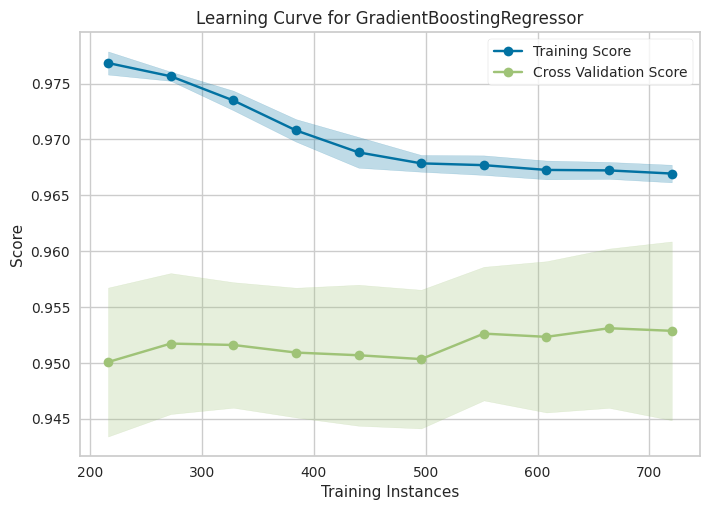

In [27]:
plot_model(best_model2, plot='learning')

### Ajuste de Hiperparámetros (Regularización y Pruning)
Optimizaremos el modelo seleccionado empleando búsqueda aleatoria para encontrar hiperparámetros que restrinjan su complejidad y maximicen su capacidad de generalización.

In [13]:
# Optimizar el modelo ganador
tuned_model = tune_model(best_model, n_iter=15, optimize='R2')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.0707,6.9578,2.6378,0.9690,0.0830,0.0629
1,2.3606,8.6740,2.9452,0.9602,0.1006,0.0770
2,2.7735,12.0726,3.4746,0.9517,0.1057,0.0849
3,2.3699,8.8525,2.9753,0.9628,0.0896,0.0700
4,2.6656,10.2128,3.1957,0.9489,0.1040,0.0850
5,2.6211,11.3147,3.3637,0.9414,0.1197,0.0914
6,2.2732,7.9399,2.8178,0.9566,0.0827,0.0635
7,2.4755,9.8164,3.1331,0.9643,0.0869,0.0693
8,2.4827,9.8299,3.1353,0.9556,0.0948,0.0753


Fitting 10 folds for each of 15 candidates, totalling 150 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


---
## 7. Diagnóstico Visual Avanzado: La Curva de Aprendizaje

La **Curva de Aprendizaje (Learning Curve)** (referencia: **Diapositiva 13**) representa el error del modelo a medida que entrenamos con más datos.

*   **Régimen 1 (Alta Varianza / Overfitting):** Gran distancia entre la curva de entrenamiento y validación.
*   **Régimen 2 (Alto Sesgo / Underfitting):** Ambas curvas convergen rápidamente pero a un nivel de error inaceptable.

Grafiquemos la curva de aprendizaje de nuestro modelo optimizado en PyCaret.

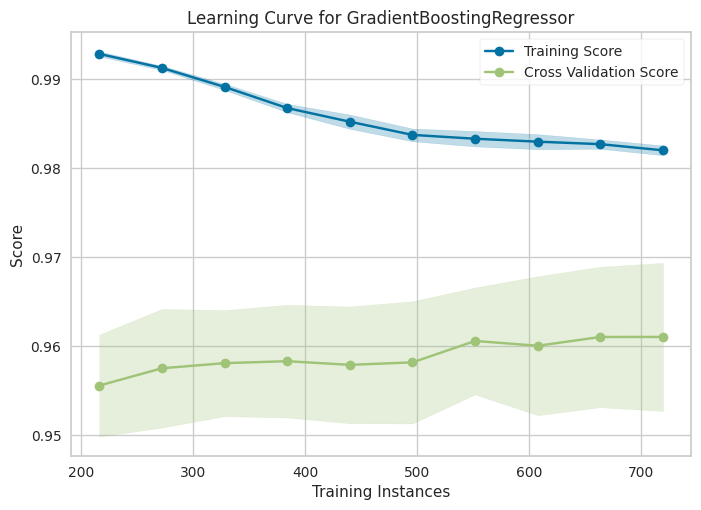

In [14]:
# Graficar la curva de aprendizaje
plot_model(tuned_model, plot='learning')

### Análisis del Gráfico de Error de Predicción
Verifiquemos cómo se distribuyen nuestras predicciones reales contra el valor real de gasto.

In [ ]:
plot_model(tuned_model, plot='error')

---
## 8. Evaluación y Desafío Final

Evaluaremos el modelo en datos de prueba de Homecenter que el algoritmo jamás vio en la fase de entrenamiento y validación.

In [ ]:
# Evaluación con datos Holdout
final_predictions = predict_model(tuned_model)

### Reto de Aprendizaje para el Alumno:
1. Modifica la celda del `setup` en PyCaret eliminando el parámetro `ignore_features` (dejando que el modelo use las variables ruidosas `id_tarjeta_tuya` y `clicks_publicidad`).
2. Vuelve a ejecutar las celdas de entrenamiento, optimización y genera nuevamente la **Curva de Aprendizaje**.
3. En tu reporte final, explica detalladamente qué cambios observas en la brecha entre las curvas de entrenamiento y validación al incluir ruido, asociándolo con la **Receta Machine Learning de la Diapositiva 15**.